# L8 LIWC and Probe Analysis

This notebook is a cleaned-up analysis notebook for the L8 adapter/probe intervention experiments. It loads LIWC annotations, token-level probe parquet files, and activation-distance parquet files, then compares probe predictions with actual LIWC annotations on generated text.

## Things To Load

- LIWC annotation CSVs from `artifacts/experiments/LIWC_annotations`.
- Baseline LIWC/text metadata from `data/LLM_mini.csv`.
- Experiment `generations_liwc.csv` files, only as provenance for matching/labels if needed.
- Token-level probe parquet files: `token_stats_adapter_new.parquet` and `token_stats_intervention_new.parquet`.
- Activation magnitude/cosine parquet files: `activation_cosine_distances.parquet`.

The adapter generation is independent of intervention mode/strength, so adapter LIWC/probe rows are deduplicated to one shared `L8_adapter` reference.

## Analyses To Perform

- Verify file coverage and experiment labels.
- Summarize LIWC annotations for the focused feature set.
- Compare each intervention's LIWC annotations against the shared layer adapter.
- Compare generated text LIWC features against the original baseline text LIWC features.
- Summarize token-level probe predictions per prompt.
- Compare prompt-level probe predictions to actual LIWC annotations on generated text.
- Compare probe-predicted intervention effects against actual LIWC intervention effects.
- Summarize activation cosine distances and vector magnitudes for the same experiments.

## Setup

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd()
if ROOT.name != "Feature_Encoding_LLM":
    ROOT = Path("/home2/faculty/owerner/Feature_Encoding_LLM")

EXPERIMENT_ROOT = ROOT / "artifacts/experiments/adapter_probe_comparison/experiments/meta-llama_Meta-Llama-3-8B-Instruct"
LIWC_ANNOTATION_DIR = ROOT / "artifacts/experiments/LIWC_annotations"
BASELINE_PATH = ROOT / "data/LLM_mini.csv"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("ROOT:", ROOT)
print("LIWC dir exists:", LIWC_ANNOTATION_DIR.exists())
print("Experiment root exists:", EXPERIMENT_ROOT.exists())

ROOT: /mnt/evafs/faculty/home/owerner/Feature_Encoding_LLM
LIWC dir exists: True
Experiment root exists: True


## Configuration

In [2]:
COLLECT_LIWC_FEATURES = ["i", "we", "female", "shehe", "Clout", "polite", "prosocial", "risk", "differ", "negate"]
PROBE_FEATURE_BY_LIWC = {
    "i": "i",
    "we": "we",
    "female": "female",
    "shehe": "shehe",
    "Clout": "clout",
    "polite": "polite",
    "prosocial": "prosocial",
    "risk": "risk",
    "differ": "differ",
    "negate": "negate",
}

# Layer 8 is the intervention layer in these experiments. Use list(range(32)) to scan every probe layer.
PROBE_LAYERS = [8]

LIWC_ANNOTATION_LABEL_OVERRIDES = {
    # Matched by exact prompt+generation text against experiment generations_liwc.csv / JSON files.
    "LIWC-22Results-generations_liwc-LIWC.csv": "L8_increase_8p0",
    "LIWC-22 Results - generations_liwc1 - LIWC Analysis.csv": "L8_decrease_16p0",
    "LIWC-22 Results - generations_liwc2 - LIWC Analysis.csv": "L8_decrease_32p0",
    "LIWC-22 Results - generations_liwc4 - LIWC Analysis.csv": "L8_increase_32p0",
    "LIWC-22 Results - generations_liwc5 - LIWC Analysis.csv": "L8_project_50p0",
    "LIWC-22 Results - generations_liwc6 - LIWC Analysis.csv": "L8_project_100p0",
    "LIWC-22 Results - generations_liwc7 - LIWC Analysis.csv": "L8_increase_16p0",
    # No current LIWC annotation file matched L8_decrease_8p0.
}

PROBE_EXPERIMENT_PATHS = {
    "L8_increase_8p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_increase_8p0/ver_2",
    "L8_increase_16p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_increase_16p0/ver_1",
    "L8_increase_32p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_increase_32p0/ver_1",
    "L8_decrease_8p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_decrease_8p0/ver_1",
    "L8_decrease_16p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_decrease_16p0/ver_1",
    "L8_decrease_32p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_decrease_32p0/ver_1",
    "L8_project_50p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_project_50p0/ver_1",
    "L8_project_100p0": EXPERIMENT_ROOT / "gender_adapter_probe_L8_project_100p0/ver_1",
}

## Helper Functions

In [3]:
def clean_liwc_annotation_label(path):
    label = path.stem
    label = re.sub(r"^LIWC-22\s*Results\s*-\s*", "", label)
    label = re.sub(r"^LIWC-22Results-", "", label)
    label = re.sub(r"\s*-\s*LIWC\s*Analysis$", "", label)
    label = re.sub(r"-LIWC$", "", label)
    label = re.sub(r"\s+", "_", label.strip())
    return label


def condition_from_source_file(value):
    value = str(value)
    if "adapter_new" in value:
        return "adapter_new"
    if "intervention_new" in value:
        return "intervention_new"
    if "baseline_old" in value:
        return "baseline_old"
    if "baseline_new" in value:
        return "baseline_new"
    return Path(value).stem.replace("generations_", "")


def parse_annotation_set_metadata(label):
    label = str(label)
    m = re.match(r"L(?P<layer>\d+)_(?P<mode>increase|decrease|project)_(?P<strength>[0-9]+p[0-9]+)", label)
    if m:
        return pd.Series({
            "intervention_layer": int(m.group("layer")),
            "intervention_mode": m.group("mode"),
            "intervention_strength": float(m.group("strength").replace("p", ".")),
        })
    m = re.match(r"L(?P<layer>\d+)_adapter", label)
    if m:
        return pd.Series({
            "intervention_layer": int(m.group("layer")),
            "intervention_mode": "adapter",
            "intervention_strength": np.nan,
        })
    return pd.Series({"intervention_layer": np.nan, "intervention_mode": np.nan, "intervention_strength": np.nan})


def parse_prompt_fields(prompt):
    prompt = str(prompt)
    out = {"gender": np.nan, "level": np.nan, "trait": np.nan, "belief": np.nan, "question": np.nan, "type": np.nan}
    m = re.search(r"your (female|male) interlocutor", prompt)
    if m:
        out["gender"] = m.group(1)
    m = re.search(r"with a (low|high) level of ([^,]+), and answer", prompt)
    if m:
        out["level"] = m.group(1)
        out["trait"] = m.group(2).strip()
    m = re.search(r'answer "(yes|no)" to the question: "([^"]+)"', prompt)
    if m:
        out["belief"] = m.group(1)
        out["question"] = m.group(2).strip()
    m = re.search(r"Use ([^\.]+) arguments", prompt)
    if m:
        out["type"] = m.group(1).strip()
    return pd.Series(out)


def heatmap(data, title, center=0, cmap="vlag", annot=False, fmt=".2f", cbar_label=None):
    if data.empty:
        print("No data for", title)
        return
    plt.figure(figsize=(min(22, 0.65 * len(data.columns) + 6), max(4, 0.35 * len(data))))
    if sns is not None:
        sns.heatmap(data, cmap=cmap, center=center, annot=annot, fmt=fmt, linewidths=0.2, cbar_kws={"label": cbar_label} if cbar_label else None)
    else:
        plt.imshow(data.fillna(0), aspect="auto", cmap="coolwarm")
        plt.xticks(range(len(data.columns)), data.columns, rotation=90)
        plt.yticks(range(len(data.index)), data.index)
        plt.colorbar(label=cbar_label)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Load LIWC Annotations

In [4]:
liwc_annotation_files = sorted(LIWC_ANNOTATION_DIR.glob("*.csv"))
print(f"Found {len(liwc_annotation_files)} LIWC annotation files")
for path in liwc_annotation_files:
    print("-", path.name)

liwc_frames = []
for path in liwc_annotation_files:
    frame = pd.read_csv(path)
    frame["liwc_annotation_file"] = path.name
    frame["liwc_annotation_stem"] = path.stem
    frame["annotation_set"] = LIWC_ANNOTATION_LABEL_OVERRIDES.get(path.name, clean_liwc_annotation_label(path))
    frame["condition"] = frame["source_file"].map(condition_from_source_file) if "source_file" in frame.columns else "unknown"
    if "text" in frame.columns:
        frame["text_len_chars"] = frame["text"].fillna("").astype(str).str.len()
    liwc_frames.append(frame)

liwc_all_raw = pd.concat(liwc_frames, ignore_index=True) if liwc_frames else pd.DataFrame()

if not liwc_all_raw.empty and "prompt" in liwc_all_raw.columns:
    parsed = liwc_all_raw["prompt"].apply(parse_prompt_fields)
    for col in parsed.columns:
        if col not in liwc_all_raw.columns:
            liwc_all_raw[col] = parsed[col]

if not liwc_all_raw.empty:
    annotation_meta = liwc_all_raw["annotation_set"].apply(parse_annotation_set_metadata)
    for col in annotation_meta.columns:
        liwc_all_raw[col] = annotation_meta[col]

metadata_cols = {
    "source_file", "record_index", "text_id", "text_kind", "tag", "avg_logprob_delta", "prompt", "text",
    "liwc_annotation_file", "liwc_annotation_stem", "annotation_set", "condition", "text_len_chars",
    "gender", "level", "trait", "belief", "question", "type", "intervention_layer", "intervention_mode", "intervention_strength",
}
liwc_numeric_cols = [c for c in liwc_all_raw.select_dtypes(include="number").columns if c not in metadata_cols and c != "Segment"]
interesting_liwc_cols = [c for c in COLLECT_LIWC_FEATURES if c in liwc_numeric_cols]
print("raw shape:", liwc_all_raw.shape)
print("focused LIWC features:", interesting_liwc_cols)
missing = [c for c in COLLECT_LIWC_FEATURES if c not in liwc_numeric_cols]
if missing:
    print("Missing requested LIWC columns:", missing)

display(liwc_all_raw.groupby(["annotation_set", "condition"], dropna=False).size().rename("rows").reset_index())

Found 7 LIWC annotation files
- LIWC-22 Results - generations_liwc1 - LIWC Analysis.csv
- LIWC-22 Results - generations_liwc2 - LIWC Analysis.csv
- LIWC-22 Results - generations_liwc4 - LIWC Analysis.csv
- LIWC-22 Results - generations_liwc5 - LIWC Analysis.csv
- LIWC-22 Results - generations_liwc6 - LIWC Analysis.csv
- LIWC-22 Results - generations_liwc7 - LIWC Analysis.csv
- LIWC-22Results-generations_liwc-LIWC.csv
raw shape: (8400, 140)
focused LIWC features: ['i', 'we', 'female', 'shehe', 'Clout', 'polite', 'prosocial', 'risk', 'differ', 'negate']


,annotation_set,condition,rows
0,L8_decrease_16p0,adapter_new,600
1,L8_decrease_16p0,intervention_new,600
2,L8_decrease_32p0,adapter_new,600
3,L8_decrease_32p0,intervention_new,600
4,L8_increase_16p0,adapter_new,600
5,L8_increase_16p0,intervention_new,600
6,L8_increase_32p0,adapter_new,600
7,L8_increase_32p0,intervention_new,600
8,L8_increase_8p0,adapter_new,600
9,L8_increase_8p0,intervention_new,600


## Deduplicate Shared Adapter Rows

In [5]:
liwc_all = liwc_all_raw.copy()
if not liwc_all.empty and {"condition", "intervention_layer", "record_index"}.issubset(liwc_all.columns):
    adapter_rows = liwc_all[liwc_all["condition"].eq("adapter_new")].copy()
    intervention_rows = liwc_all[~liwc_all["condition"].eq("adapter_new")].copy()

    adapter_rows = adapter_rows.sort_values(["intervention_layer", "record_index", "annotation_set"])
    adapter_rows = adapter_rows.drop_duplicates(["intervention_layer", "condition", "record_index"], keep="first")
    adapter_rows["source_annotation_set"] = adapter_rows["annotation_set"]
    adapter_rows["annotation_set"] = adapter_rows["intervention_layer"].map(lambda x: f"L{int(x)}_adapter" if pd.notna(x) else "adapter")
    adapter_rows["intervention_mode"] = "adapter"
    adapter_rows["intervention_strength"] = np.nan

    intervention_rows["source_annotation_set"] = intervention_rows["annotation_set"]
    liwc_all = pd.concat([adapter_rows, intervention_rows], ignore_index=True)

print("deduplicated shape:", liwc_all.shape)
display(
    liwc_all
    .groupby(["annotation_set", "condition"], dropna=False)
    .agg(rows=("text", "size"), unique_prompts=("record_index", "nunique"), mean_wc=("WC", "mean"))
    .reset_index()
)

deduplicated shape: (4800, 141)


,annotation_set,condition,rows,unique_prompts,mean_wc
0,L8_adapter,adapter_new,600,600,382.596667
1,L8_decrease_16p0,intervention_new,600,600,427.760000
2,L8_decrease_32p0,intervention_new,600,600,444.461667
3,L8_increase_16p0,intervention_new,600,600,380.576667
4,L8_increase_32p0,intervention_new,600,600,394.438333
5,L8_increase_8p0,intervention_new,600,600,379.018333
6,L8_project_100p0,intervention_new,600,600,386.326667
7,L8_project_50p0,intervention_new,600,600,389.225000


## LIWC Summary By Condition

,,i,we,female,shehe,Clout,polite,prosocial,risk,differ,negate
annotation_set,condition,,,,,,,,,,
L8_adapter,adapter_new,1.511,1.078,0.492,0.240,69.046,0.191,2.065,0.854,3.731,1.190
L8_decrease_16p0,intervention_new,3.067,1.657,0.817,0.639,71.947,0.179,1.280,0.728,3.792,1.264
L8_decrease_32p0,intervention_new,3.765,1.695,0.550,0.428,66.411,0.156,0.960,0.477,3.743,1.247
L8_increase_16p0,intervention_new,1.123,2.057,0.968,0.731,76.593,0.105,1.503,1.105,3.691,1.397
L8_increase_32p0,intervention_new,0.517,2.243,0.448,0.339,72.067,0.154,1.320,1.129,3.303,1.492
L8_increase_8p0,intervention_new,1.633,1.768,0.914,0.758,74.085,0.136,1.723,0.967,3.843,1.344
L8_project_100p0,intervention_new,2.122,1.642,0.963,0.777,72.308,0.143,1.542,0.899,3.947,1.358
L8_project_50p0,intervention_new,2.052,1.627,0.996,0.773,72.174,0.163,1.564,0.924,4.028,1.385


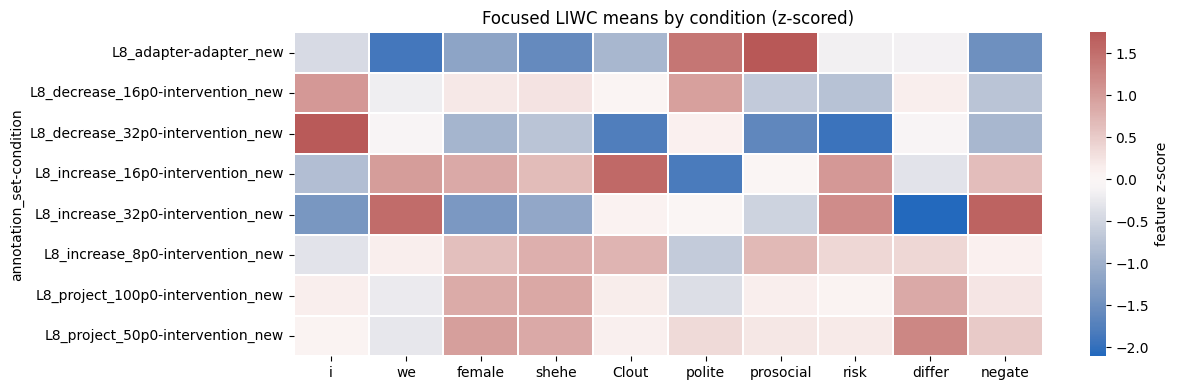

In [6]:
liwc_means_by_set = (
    liwc_all.groupby(["annotation_set", "condition"], dropna=False)[interesting_liwc_cols]
    .mean()
    .sort_index()
)
display(liwc_means_by_set.round(3))

liwc_means_z = (liwc_means_by_set - liwc_means_by_set.mean(axis=0)) / liwc_means_by_set.std(axis=0).replace(0, np.nan)
heatmap(liwc_means_z, "Focused LIWC means by condition (z-scored)", center=0, cbar_label="feature z-score")

## LIWC Intervention Effects Relative To Adapter

,annotation_set,intervention_layer,intervention_mode,intervention_strength,feature,mean,median,std
0,L8_decrease_16p0,8,decrease,16.0,Clout,2.900,3.625,24.981
1,L8_decrease_16p0,8,decrease,16.0,differ,0.061,0.095,1.988
2,L8_decrease_16p0,8,decrease,16.0,female,0.325,0.000,1.008
3,L8_decrease_16p0,8,decrease,16.0,i,1.556,1.605,2.333
4,L8_decrease_16p0,8,decrease,16.0,negate,0.074,0.200,1.357
...,...,...,...,...,...,...,...,...
65,L8_project_50p0,8,project,50.0,polite,-0.028,0.000,0.402
66,L8_project_50p0,8,project,50.0,prosocial,-0.501,-0.435,1.357
67,L8_project_50p0,8,project,50.0,risk,0.070,0.000,0.893
68,L8_project_50p0,8,project,50.0,shehe,0.533,0.320,0.948


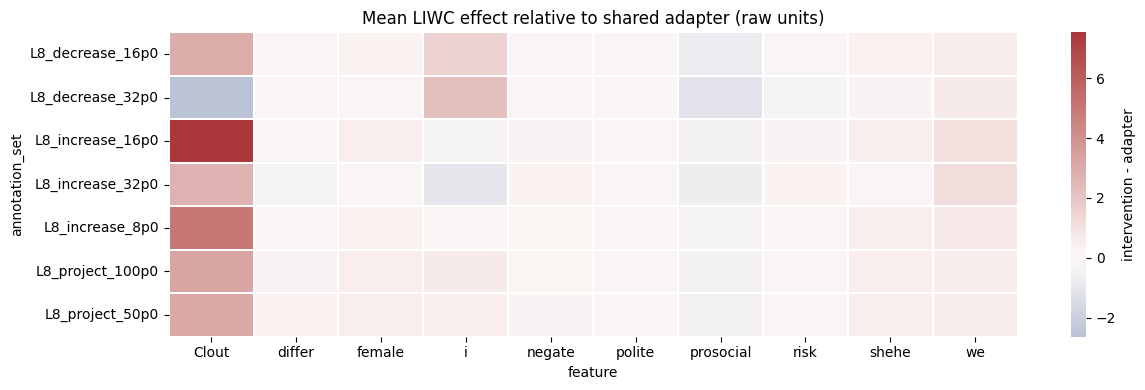

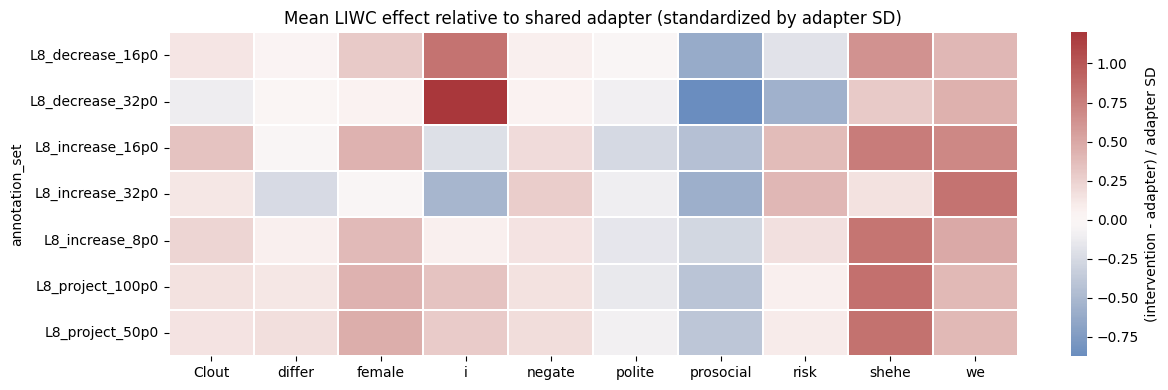

In [8]:
adapter_liwc = (
    liwc_all[liwc_all["condition"].eq("adapter_new")]
    [["intervention_layer", "record_index"] + interesting_liwc_cols]
    .drop_duplicates(["intervention_layer", "record_index"])
)
intervention_liwc = (
    liwc_all[liwc_all["condition"].eq("intervention_new")]
    [["annotation_set", "intervention_layer", "intervention_mode", "intervention_strength", "record_index"] + interesting_liwc_cols]
    .drop_duplicates(["annotation_set", "record_index"])
)
liwc_effect_wide = intervention_liwc.merge(adapter_liwc, on=["intervention_layer", "record_index"], how="inner", suffixes=("_intervention", "_adapter"))

liwc_effect_rows = []
for feature in interesting_liwc_cols:
    temp = liwc_effect_wide[["annotation_set", "intervention_layer", "intervention_mode", "intervention_strength", "record_index"]].copy()
    temp["feature"] = feature
    temp["liwc_delta_vs_adapter"] = liwc_effect_wide[f"{feature}_intervention"] - liwc_effect_wide[f"{feature}_adapter"]
    liwc_effect_rows.append(temp)
liwc_effects = pd.concat(liwc_effect_rows, ignore_index=True) if liwc_effect_rows else pd.DataFrame()

liwc_effect_summary = (
    liwc_effects.groupby(["annotation_set", "intervention_layer", "intervention_mode", "intervention_strength", "feature"], dropna=False)["liwc_delta_vs_adapter"]
    .agg(mean="mean", median="median", std="std")
    .reset_index()
)
display(liwc_effect_summary.round(3))

liwc_effect_heat = liwc_effect_summary.pivot(index="annotation_set", columns="feature", values="mean")
heatmap(liwc_effect_heat, "Mean LIWC effect relative to shared adapter (raw units)", center=0, cbar_label="intervention - adapter")

# Standardize each feature's effect by the prompt-level spread of that feature in the shared adapter texts.
# This puts Clout and percentage-like LIWC categories on a comparable scale.
adapter_feature_std = adapter_liwc[interesting_liwc_cols].std().replace(0, np.nan)
liwc_effect_heat_standardized = liwc_effect_heat.divide(adapter_feature_std, axis="columns")
heatmap(
    liwc_effect_heat_standardized,
    "Mean LIWC effect relative to shared adapter (standardized by adapter SD)",
    center=0,
    cbar_label="(intervention - adapter) / adapter SD",
)

## Generated Text vs Original Baseline LIWC

,annotation_set,condition,feature,generated_minus_baseline
0,L8_adapter,adapter_new,Clout,-6.985
1,L8_adapter,adapter_new,differ,0.282
2,L8_adapter,adapter_new,female,-0.291
3,L8_adapter,adapter_new,i,-0.143
4,L8_adapter,adapter_new,negate,0.319
...,...,...,...,...
75,L8_project_50p0,intervention_new,polite,-0.070
76,L8_project_50p0,intervention_new,prosocial,-0.375
77,L8_project_50p0,intervention_new,risk,-0.120
78,L8_project_50p0,intervention_new,shehe,0.482


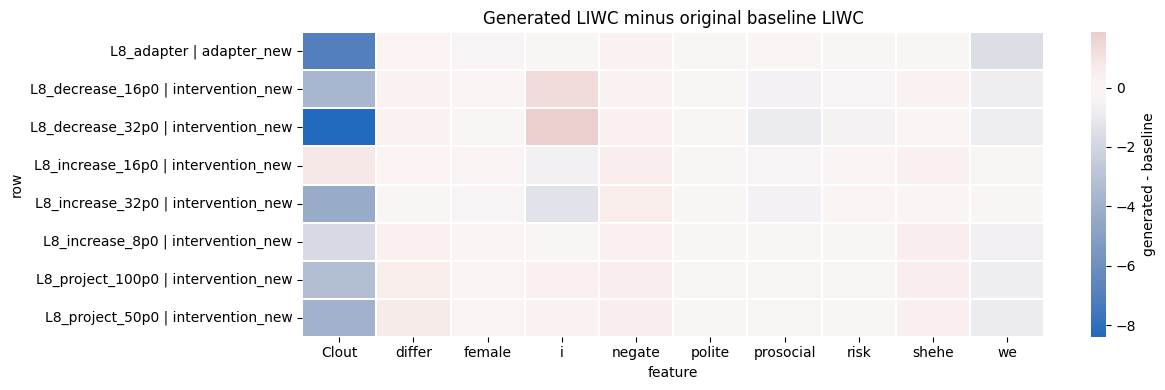

In [9]:
liwc_generated_vs_baseline = pd.DataFrame()
if BASELINE_PATH.exists() and not liwc_all.empty:
    baseline = pd.read_csv(BASELINE_PATH)
    baseline = baseline.rename(columns={
        "analytic": "Analytic",
        "clout": "Clout",
        "authentic": "Authentic",
        "tone": "Tone",
        "cognition": "Cognition",
        "affect": "Affect",
        "pronoun_LIWC": "pronoun",
    })
    baseline = baseline.loc[:, ~baseline.columns.duplicated()]
    key_cols = ["gender", "level", "trait", "belief", "question", "type"]
    available_keys = [c for c in key_cols if c in baseline.columns and c in liwc_all.columns]
    baseline_features = [c for c in interesting_liwc_cols if c in baseline.columns]
    for col in baseline_features:
        baseline[col] = pd.to_numeric(baseline[col], errors="coerce")

    baseline_small = baseline[available_keys + baseline_features].drop_duplicates(available_keys)
    merged = liwc_all.merge(baseline_small, on=available_keys, how="left", suffixes=("_generated", "_baseline"))
    rows = []
    for feature in baseline_features:
        gen_col = f"{feature}_generated"
        base_col = f"{feature}_baseline"
        temp = merged[["annotation_set", "condition", "record_index", gen_col, base_col]].copy()
        temp["feature"] = feature
        temp["generated_minus_baseline"] = temp[gen_col] - temp[base_col]
        rows.append(temp[["annotation_set", "condition", "record_index", "feature", "generated_minus_baseline"]])
    liwc_generated_vs_baseline = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

if not liwc_generated_vs_baseline.empty:
    base_delta_summary = (
        liwc_generated_vs_baseline.groupby(["annotation_set", "condition", "feature"])["generated_minus_baseline"]
        .mean()
        .reset_index()
    )
    display(base_delta_summary.round(3))
    base_heat = base_delta_summary.assign(row=lambda d: d["annotation_set"] + " | " + d["condition"]).pivot(index="row", columns="feature", values="generated_minus_baseline")
    heatmap(base_heat, "Generated LIWC minus original baseline LIWC", center=0, cbar_label="generated - baseline")
else:
    print("No baseline comparison available.")

## Load Probe Prediction Parquets

In [10]:
probe_cols = []
probe_col_to_meta = {}
for liwc_feature, probe_feature in PROBE_FEATURE_BY_LIWC.items():
    for layer in PROBE_LAYERS:
        col = f"{probe_feature}_L{layer}"
        probe_cols.append(col)
        probe_col_to_meta[col] = (liwc_feature, probe_feature, layer)

base_probe_cols = ["prompt_index", "token_index", "is_special", "logprob", "entropy"]


def parquet_columns(path):
    try:
        import pyarrow.parquet as pq
        return pq.ParquetFile(path).schema.names
    except Exception:
        return pd.read_parquet(path).columns.tolist()


def read_probe_prompt_summary(path, annotation_set, condition):
    parquet_path = path / f"token_stats_{condition}.parquet"
    if not parquet_path.exists():
        print("missing", parquet_path)
        return pd.DataFrame()
    available = parquet_columns(parquet_path)
    selected_probe_cols = [c for c in probe_cols if c in available]
    selected_cols = [c for c in base_probe_cols if c in available] + selected_probe_cols
    df = pd.read_parquet(parquet_path, columns=selected_cols)
    if "is_special" in df.columns:
        df = df[~df["is_special"].fillna(False)].copy()
    mean_cols = selected_probe_cols + [c for c in ["logprob", "entropy"] if c in df.columns]
    summary = df.groupby("prompt_index", dropna=False)[mean_cols].mean().reset_index()
    summary = summary.rename(columns={"prompt_index": "record_index", "logprob": "mean_token_logprob", "entropy": "mean_token_entropy"})
    summary["annotation_set"] = annotation_set
    summary["condition"] = condition
    meta = parse_annotation_set_metadata(annotation_set)
    for col, val in meta.items():
        summary[col] = val
    return summary

probe_prompt_frames = []
adapter_source = PROBE_EXPERIMENT_PATHS.get("L8_increase_8p0")
if adapter_source is not None:
    probe_prompt_frames.append(read_probe_prompt_summary(adapter_source, "L8_adapter", "adapter_new"))

for annotation_set in sorted(liwc_all["annotation_set"].unique()):
    if annotation_set == "L8_adapter":
        continue
    path = PROBE_EXPERIMENT_PATHS.get(annotation_set)
    if path is not None:
        probe_prompt_frames.append(read_probe_prompt_summary(path, annotation_set, "intervention_new"))

probe_prompt_summary = pd.concat([x for x in probe_prompt_frames if not x.empty], ignore_index=True) if probe_prompt_frames else pd.DataFrame()
print("probe prompt summary shape:", probe_prompt_summary.shape)
display(probe_prompt_summary.groupby(["annotation_set", "condition"], dropna=False).size().rename("prompts").reset_index())
probe_prompt_summary.head()

probe prompt summary shape: (4800, 18)


,annotation_set,condition,prompts
0,L8_adapter,adapter_new,600
1,L8_decrease_16p0,intervention_new,600
2,L8_decrease_32p0,intervention_new,600
3,L8_increase_16p0,intervention_new,600
4,L8_increase_32p0,intervention_new,600
5,L8_increase_8p0,intervention_new,600
6,L8_project_100p0,intervention_new,600
7,L8_project_50p0,intervention_new,600


,record_index,i_L8,we_L8,female_L8,shehe_L8,clout_L8,polite_L8,prosocial_L8,risk_L8,differ_L8,negate_L8,mean_token_logprob,mean_token_entropy,annotation_set,condition,intervention_layer,intervention_mode,intervention_strength
0,0,1.415094,1.405809,0.934488,0.629963,60.171715,0.346811,2.073302,0.906021,4.846613,1.429514,-0.363392,0.820268,L8_adapter,adapter_new,8,adapter,NaN
1,1,1.403043,1.439758,0.982883,0.668400,61.250271,0.356237,2.062017,0.914709,4.742885,1.380272,-2.638371,0.755750,L8_adapter,adapter_new,8,adapter,NaN
2,2,1.415152,1.519686,0.929435,0.627669,61.868462,0.364462,2.080616,0.903992,4.764413,1.383981,-0.329962,0.725457,L8_adapter,adapter_new,8,adapter,NaN
3,3,1.317619,1.325890,0.905833,0.587273,59.410179,0.338246,2.029652,0.922686,4.761581,1.375159,-8.456080,0.506498,L8_adapter,adapter_new,8,adapter,NaN
4,4,1.305569,1.362155,0.955381,0.626232,60.532520,0.347776,2.018260,0.932404,4.654770,1.324895,-8.606813,0.488634,L8_adapter,adapter_new,8,adapter,NaN


## Join Probe Predictions To LIWC Annotations

In [11]:
probe_long_rows = []
for col, (liwc_feature, probe_feature, layer) in probe_col_to_meta.items():
    if col not in probe_prompt_summary.columns:
        continue
    temp = probe_prompt_summary[["annotation_set", "condition", "record_index", "intervention_layer", "intervention_mode", "intervention_strength", col]].copy()
    temp = temp.rename(columns={col: "probe_prediction_mean"})
    temp["liwc_feature"] = liwc_feature
    temp["probe_feature"] = probe_feature
    temp["probe_layer"] = layer
    probe_long_rows.append(temp)
probe_prompt_long = pd.concat(probe_long_rows, ignore_index=True) if probe_long_rows else pd.DataFrame()

actual_liwc_long = liwc_all.melt(
    id_vars=["annotation_set", "condition", "record_index", "intervention_layer", "intervention_mode", "intervention_strength"],
    value_vars=interesting_liwc_cols,
    var_name="liwc_feature",
    value_name="liwc_value",
)

probe_vs_liwc = probe_prompt_long.merge(
    actual_liwc_long,
    on=["annotation_set", "condition", "record_index", "intervention_layer", "intervention_mode", "intervention_strength", "liwc_feature"],
    how="inner",
)
print("probe vs LIWC shape:", probe_vs_liwc.shape)
display(probe_vs_liwc.head())

probe vs LIWC shape: (48000, 11)


,annotation_set,condition,record_index,intervention_layer,intervention_mode,intervention_strength,probe_prediction_mean,liwc_feature,probe_feature,probe_layer,liwc_value
0,L8_adapter,adapter_new,0,8,adapter,NaN,1.415094,i,i,8,0.23
1,L8_adapter,adapter_new,1,8,adapter,NaN,1.403043,i,i,8,0.25
2,L8_adapter,adapter_new,2,8,adapter,NaN,1.415152,i,i,8,2.78
3,L8_adapter,adapter_new,3,8,adapter,NaN,1.317619,i,i,8,2.02
4,L8_adapter,adapter_new,4,8,adapter,NaN,1.305569,i,i,8,1.99


## Probe Prediction vs Actual LIWC Annotation

,annotation_set,condition,liwc_feature,probe_layer,n,r2,mae,rmse,bias,slope,intercept,pearson_r,spearman_r,probe_mean,liwc_mean
0,L8_adapter,adapter_new,Clout,8,600.0,-0.085,19.804,23.070,-7.175,4.524,-210.875,0.225,0.228,61.871,69.046
10,L8_decrease_16p0,intervention_new,Clout,8,600.0,-0.848,22.422,25.424,-17.497,3.989,-145.248,0.250,0.211,54.450,71.947
20,L8_decrease_32p0,intervention_new,Clout,8,600.0,-0.503,26.005,30.017,-17.546,3.221,-90.986,0.142,0.139,48.865,66.411
30,L8_increase_16p0,intervention_new,Clout,8,597.0,-0.214,16.925,19.698,-8.697,2.907,-120.812,0.200,0.182,67.895,76.593
40,L8_increase_32p0,intervention_new,Clout,8,595.0,0.013,20.344,24.963,1.819,4.751,-278.953,0.220,0.175,73.886,72.067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,L8_increase_16p0,intervention_new,we,8,600.0,-0.009,1.245,1.719,-0.380,3.004,-2.982,0.268,0.281,1.678,2.057
49,L8_increase_32p0,intervention_new,we,8,600.0,0.012,1.713,2.385,-0.324,4.676,-6.730,0.280,0.284,1.919,2.243
59,L8_increase_8p0,intervention_new,we,8,600.0,0.047,1.109,1.523,-0.231,3.995,-4.373,0.398,0.365,1.537,1.768
69,L8_project_100p0,intervention_new,we,8,600.0,0.041,1.005,1.334,-0.271,3.680,-3.406,0.414,0.368,1.372,1.642


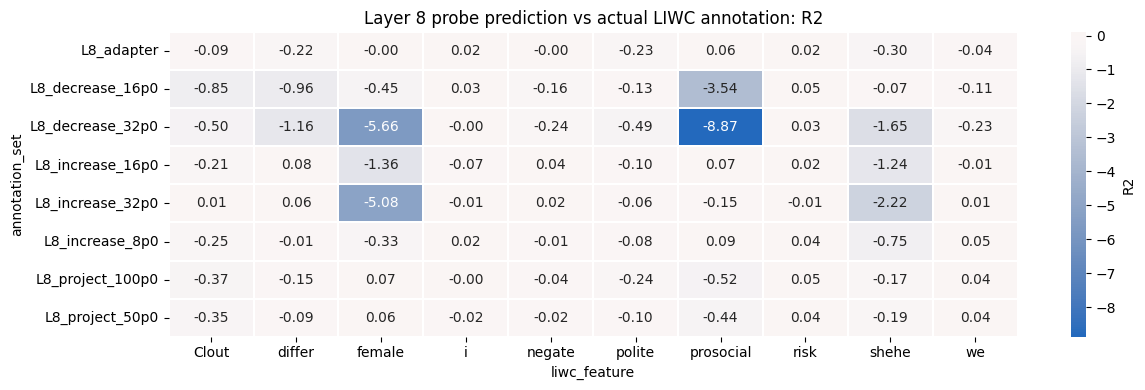

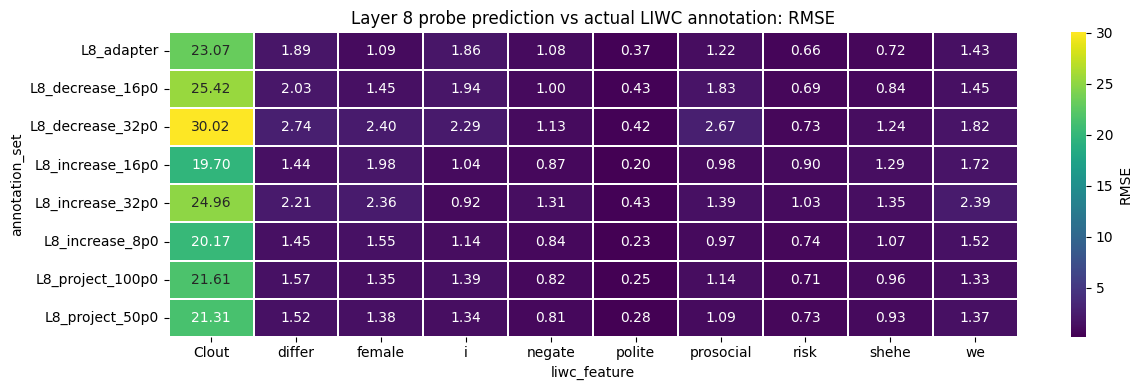

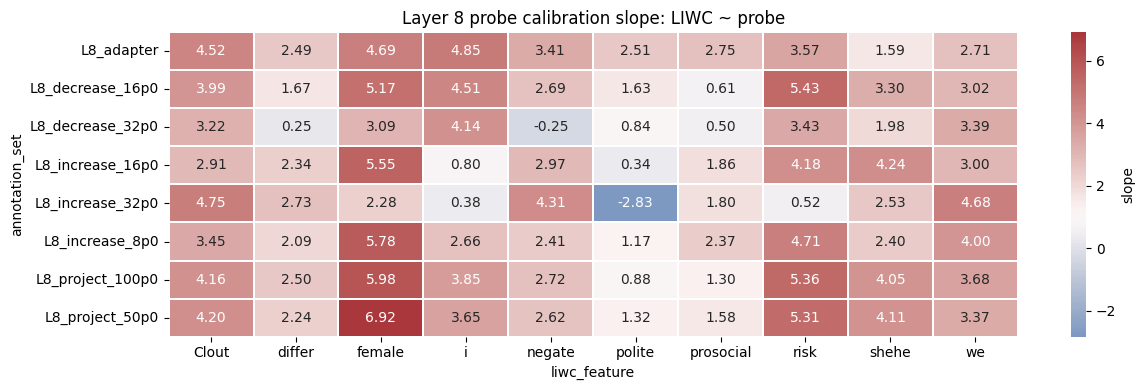

In [13]:
def regression_probe_metrics(g):
    y = pd.to_numeric(g["liwc_value"], errors="coerce").to_numpy(dtype=float)
    yhat = pd.to_numeric(g["probe_prediction_mean"], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(y) & np.isfinite(yhat)
    y = y[mask]
    yhat = yhat[mask]
    n = len(y)
    if n == 0:
        return pd.Series({
            "n": 0,
            "r2": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "bias": np.nan,
            "slope": np.nan,
            "intercept": np.nan,
            "pearson_r": np.nan,
            "spearman_r": np.nan,
            "probe_mean": np.nan,
            "liwc_mean": np.nan,
        })
    residual = y - yhat
    sse = np.square(residual).sum()
    sst = np.square(y - y.mean()).sum()
    r2 = 1.0 - sse / sst if sst > 0 else np.nan
    rmse = np.sqrt(np.square(residual).mean())
    mae = np.abs(residual).mean()
    bias = (yhat - y).mean()
    if n >= 2 and np.nanstd(yhat) > 0:
        slope, intercept = np.polyfit(yhat, y, 1)
    else:
        slope, intercept = np.nan, np.nan
    return pd.Series({
        "n": n,
        "r2": r2,
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "slope": slope,
        "intercept": intercept,
        "pearson_r": pd.Series(yhat).corr(pd.Series(y), method="pearson"),
        "spearman_r": pd.Series(yhat).corr(pd.Series(y), method="spearman"),
        "probe_mean": yhat.mean(),
        "liwc_mean": y.mean(),
    })

if not probe_vs_liwc.empty:
    probe_metric_summary = (
        probe_vs_liwc.groupby(["annotation_set", "condition", "liwc_feature", "probe_layer"], dropna=False)
        .apply(regression_probe_metrics, include_groups=False)
        .reset_index()
    )
    # Keep the old name as an alias so downstream exploratory cells do not break.
    corr_summary = probe_metric_summary
    display(probe_metric_summary.sort_values(["liwc_feature", "annotation_set", "probe_layer"]).round(3))

    r2_heat = probe_metric_summary[probe_metric_summary["probe_layer"].eq(8)].pivot_table(
        index="annotation_set", columns="liwc_feature", values="r2", aggfunc="mean"
    )
    heatmap(r2_heat, "Layer 8 probe prediction vs actual LIWC annotation: R2", center=0, annot=True, cbar_label="R2")

    rmse_heat = probe_metric_summary[probe_metric_summary["probe_layer"].eq(8)].pivot_table(
        index="annotation_set", columns="liwc_feature", values="rmse", aggfunc="mean"
    )
    heatmap(rmse_heat, "Layer 8 probe prediction vs actual LIWC annotation: RMSE", center=None, cmap="viridis", annot=True, cbar_label="RMSE")

    slope_heat = probe_metric_summary[probe_metric_summary["probe_layer"].eq(8)].pivot_table(
        index="annotation_set", columns="liwc_feature", values="slope", aggfunc="mean"
    )
    heatmap(slope_heat, "Layer 8 probe calibration slope: LIWC ~ probe", center=1, annot=True, cbar_label="slope")
else:
    probe_metric_summary = pd.DataFrame()
    corr_summary = pd.DataFrame()
    print("No probe/LIWC matches available.")

## Probe-Predicted Effects vs Actual LIWC Effects

In [ ]:
if not probe_vs_liwc.empty:
    adapter_probe = probe_vs_liwc[probe_vs_liwc["annotation_set"].eq("L8_adapter")][["record_index", "liwc_feature", "probe_layer", "probe_prediction_mean", "liwc_value"]].copy()
    adapter_probe = adapter_probe.rename(columns={"probe_prediction_mean": "adapter_probe_prediction", "liwc_value": "adapter_liwc_value"})
    intervention_probe = probe_vs_liwc[~probe_vs_liwc["annotation_set"].eq("L8_adapter")].copy()
    probe_liwc_effects = intervention_probe.merge(adapter_probe, on=["record_index", "liwc_feature", "probe_layer"], how="inner")
    probe_liwc_effects["probe_delta_vs_adapter"] = probe_liwc_effects["probe_prediction_mean"] - probe_liwc_effects["adapter_probe_prediction"]
    probe_liwc_effects["liwc_delta_vs_adapter"] = probe_liwc_effects["liwc_value"] - probe_liwc_effects["adapter_liwc_value"]

    effect_corr = (
        probe_liwc_effects.groupby(["annotation_set", "liwc_feature", "probe_layer"], dropna=False)
        .apply(lambda g: pd.Series({
            "n": len(g),
            "delta_spearman_r": g["probe_delta_vs_adapter"].corr(g["liwc_delta_vs_adapter"], method="spearman"),
            "mean_probe_delta": g["probe_delta_vs_adapter"].mean(),
            "mean_liwc_delta": g["liwc_delta_vs_adapter"].mean(),
        }), include_groups=False)
        .reset_index()
    )
    display(effect_corr.sort_values(["liwc_feature", "annotation_set", "probe_layer"]).round(3))
    effect_heat = effect_corr[effect_corr["probe_layer"].eq(8)].pivot_table(index="annotation_set", columns="liwc_feature", values="delta_spearman_r", aggfunc="mean")
    heatmap(effect_heat, "Probe-predicted effect vs actual LIWC effect", center=0, annot=True, cbar_label="Spearman r of deltas")
else:
    probe_liwc_effects = pd.DataFrame()
    effect_corr = pd.DataFrame()
    print("No effect comparison available.")

## Original Baseline Text: Probe Prediction vs LIWC Annotation

This checks the probe on the original held-out/baseline text (`token_stats_baseline_old.parquet`) instead of generated intervention text. If R2 is also near zero here, the issue is likely probe calibration, layer choice, aggregation, or target mismatch rather than generated-text distribution shift alone.

In [ ]:
# Use one experiment's baseline_old parquet because baseline_old is independent of intervention mode.
baseline_probe_source = PROBE_EXPERIMENT_PATHS.get("L8_increase_8p0")

baseline = pd.read_csv(BASELINE_PATH).rename(columns={
    "analytic": "Analytic",
    "clout": "Clout",
    "authentic": "Authentic",
    "tone": "Tone",
    "cognition": "Cognition",
    "affect": "Affect",
    "pronoun_LIWC": "pronoun",
})
baseline = baseline.loc[:, ~baseline.columns.duplicated()].copy()
baseline = baseline.reset_index().rename(columns={"index": "record_index"})
for feature in interesting_liwc_cols:
    if feature in baseline.columns:
        baseline[feature] = pd.to_numeric(baseline[feature], errors="coerce")

original_probe_summary = read_probe_prompt_summary(baseline_probe_source, "original_baseline", "baseline_old")
original_probe_summary["annotation_set"] = "original_baseline"
original_probe_summary["condition"] = "baseline_old"

original_probe_rows = []
for col, (liwc_feature, probe_feature, layer) in probe_col_to_meta.items():
    if col not in original_probe_summary.columns or liwc_feature not in baseline.columns:
        continue
    temp = original_probe_summary[["annotation_set", "condition", "record_index", col]].merge(
        baseline[["record_index", liwc_feature]],
        on="record_index",
        how="inner",
    )
    temp = temp.rename(columns={col: "probe_prediction_mean", liwc_feature: "liwc_value"})
    temp["liwc_feature"] = liwc_feature
    temp["probe_feature"] = probe_feature
    temp["probe_layer"] = layer
    original_probe_rows.append(temp)

original_probe_vs_liwc = pd.concat(original_probe_rows, ignore_index=True) if original_probe_rows else pd.DataFrame()
print("original_probe_summary shape:", original_probe_summary.shape)
print("original_probe_vs_liwc shape:", original_probe_vs_liwc.shape)

def original_metric_group(g):
    return regression_probe_metrics(g)

if not original_probe_vs_liwc.empty:
    original_probe_metric_summary = (
        original_probe_vs_liwc.groupby(["annotation_set", "condition", "liwc_feature", "probe_layer"], dropna=False)
        .apply(original_metric_group, include_groups=False)
        .reset_index()
    )
    display(original_probe_metric_summary.sort_values(["liwc_feature", "probe_layer"]).round(3))

    for metric, title, center, cmap in [
        ("r2", "Original baseline text: probe prediction R2", 0, "vlag"),
        ("rmse", "Original baseline text: probe prediction RMSE", None, "viridis"),
        ("mae", "Original baseline text: probe prediction MAE", None, "viridis"),
        ("slope", "Original baseline text: calibration slope LIWC ~ probe", 1, "vlag"),
        ("bias", "Original baseline text: mean prediction bias", 0, "vlag"),
    ]:
        metric_heat = original_probe_metric_summary.pivot_table(
            index="annotation_set", columns="liwc_feature", values=metric, aggfunc="mean"
        )
        heatmap(metric_heat, title, center=center, cmap=cmap, annot=True, cbar_label=metric)
else:
    original_probe_metric_summary = pd.DataFrame()
    print("No original baseline probe/LIWC matches available.")

## Original Baseline Text: Token-Level Probe Check

The probe metadata R2 is computed at token level: each text's LIWC label is repeated for every valid token. This section evaluates `token_stats_baseline_old.parquet` the same way, so it is the closest check for whether probe loading/scoring matches training.

In [ ]:
baseline_token_path = baseline_probe_source / "token_stats_baseline_old.parquet"
selected_probe_cols = [c for c in probe_cols if c in parquet_columns(baseline_token_path)]
selected_cols = ["prompt_index", "token_index", "is_special"] + selected_probe_cols
baseline_token_probe = pd.read_parquet(baseline_token_path, columns=selected_cols)
if "is_special" in baseline_token_probe.columns:
    baseline_token_probe = baseline_token_probe[~baseline_token_probe["is_special"].fillna(False)].copy()
baseline_token_probe = baseline_token_probe.rename(columns={"prompt_index": "record_index"})

original_token_rows = []
for col, (liwc_feature, probe_feature, layer) in probe_col_to_meta.items():
    if col not in baseline_token_probe.columns or liwc_feature not in baseline.columns:
        continue
    temp = baseline_token_probe[["record_index", "token_index", col]].merge(
        baseline[["record_index", liwc_feature]],
        on="record_index",
        how="inner",
    )
    temp = temp.rename(columns={col: "probe_prediction", liwc_feature: "liwc_value"})
    temp["liwc_feature"] = liwc_feature
    temp["probe_feature"] = probe_feature
    temp["probe_layer"] = layer
    original_token_rows.append(temp)

original_token_probe_vs_liwc = pd.concat(original_token_rows, ignore_index=True) if original_token_rows else pd.DataFrame()
print("original_token_probe_vs_liwc shape:", original_token_probe_vs_liwc.shape)

if not original_token_probe_vs_liwc.empty:
    original_token_metric_summary = (
        original_token_probe_vs_liwc
        .rename(columns={"probe_prediction": "probe_prediction_mean"})
        .groupby(["liwc_feature", "probe_layer"], dropna=False)
        .apply(regression_probe_metrics, include_groups=False)
        .reset_index()
    )
    display(original_token_metric_summary.sort_values(["liwc_feature", "probe_layer"]).round(3))

    for metric, title, center, cmap in [
        ("r2", "Original baseline token-level probe R2", 0, "vlag"),
        ("rmse", "Original baseline token-level probe RMSE", None, "viridis"),
        ("mae", "Original baseline token-level probe MAE", None, "viridis"),
        ("slope", "Original baseline token-level calibration slope LIWC ~ probe", 1, "vlag"),
    ]:
        metric_heat = original_token_metric_summary.pivot_table(index="probe_layer", columns="liwc_feature", values=metric, aggfunc="mean")
        heatmap(metric_heat, title, center=center, cmap=cmap, annot=True, cbar_label=metric)
else:
    original_token_metric_summary = pd.DataFrame()
    print("No original token-level probe/LIWC matches available.")

## Activation Magnitudes And Cosine Distances

In [ ]:
activation_frames = []
for annotation_set, path in PROBE_EXPERIMENT_PATHS.items():
    parquet_path = path / "activation_cosine_distances.parquet"
    if not parquet_path.exists():
        continue
    frame = pd.read_parquet(parquet_path)
    frame["annotation_set"] = annotation_set
    meta = parse_annotation_set_metadata(annotation_set)
    for col, val in meta.items():
        frame[col] = val
    activation_frames.append(frame)

activation_distances = pd.concat(activation_frames, ignore_index=True) if activation_frames else pd.DataFrame()
print("activation distances shape:", activation_distances.shape)

if not activation_distances.empty:
    activation_summary = (
        activation_distances.groupby(["annotation_set", "pair", "layer"], dropna=False)
        .agg(
            cosine_distance_mean=("cosine_distance_mean", "mean"),
            cosine_similarity_mean=("cosine_similarity_mean", "mean"),
            delta_norm_mean=("delta_norm_mean", "mean"),
            relative_delta_norm_mean=("relative_delta_norm_mean", "mean"),
        )
        .reset_index()
    )
    display(activation_summary.head())

    for metric in ["cosine_distance_mean", "delta_norm_mean", "relative_delta_norm_mean"]:
        plot_data = activation_summary[activation_summary["pair"].eq("original_vs_intervention")]
        if plot_data.empty or metric not in plot_data.columns:
            continue
        plt.figure(figsize=(11, 5))
        if sns is not None:
            sns.lineplot(data=plot_data, x="layer", y=metric, hue="annotation_set", marker="o")
        else:
            for label, group in plot_data.groupby("annotation_set"):
                plt.plot(group["layer"], group[metric], marker="o", label=label)
            plt.legend()
        plt.title(f"{metric}: original_vs_intervention")
        plt.tight_layout()
        plt.show()
else:
    activation_summary = pd.DataFrame()
    print("No activation distance parquets found.")

## Output Objects

Important dataframes created by this notebook:

- `liwc_all_raw`: all LIWC rows exactly as loaded.
- `liwc_all`: LIWC rows with duplicate adapters removed.
- `liwc_effects`: prompt-level LIWC intervention-minus-adapter effects.
- `liwc_effect_summary`: mean/median/std LIWC effects by experiment and feature.
- `liwc_generated_vs_baseline`: generated text LIWC minus original baseline LIWC.
- `probe_prompt_summary`: prompt-level token-probe predictions.
- `probe_vs_liwc`: prompt-level probe predictions joined to actual LIWC annotations.
- `corr_summary`: correlation of probe predictions with actual LIWC annotations.
- `probe_liwc_effects`: prompt-level probe and LIWC effects relative to adapter.
- `effect_corr`: correlation of probe-predicted effects with actual LIWC effects.
- `activation_distances` and `activation_summary`: cosine/magnitude summaries from activation parquets.